<>:61: SyntaxWarning: invalid escape sequence '\$'
<>:61: SyntaxWarning: invalid escape sequence '\$'
C:\Users\WALTON\AppData\Local\Temp\ipykernel_1616\2678460625.py:61: SyntaxWarning: invalid escape sequence '\$'
  plt.ylabel('Per Capita Income (US\$)')


   year  per capita income (US$)
0  1970              3399.299037
1  1971              3768.297935
2  1972              4251.175484
3  1973              4804.463248
4  1974              5576.514583
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     47 non-null     int64  
 1   per capita income (US$)  47 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 884.0 bytes
None

R-squared (R^2) Score: 0.8751771396846304
Mean Absolute Error (MAE): 3240.91399747583
Root Mean Squared Error (RMSE): 3892.0194690913613
R-squared (R^2) Score on full dataset: 0.8906178144427535
Model Coefficient (slope): 815.1425130089494
Model Intercept: -1605560.1987964248


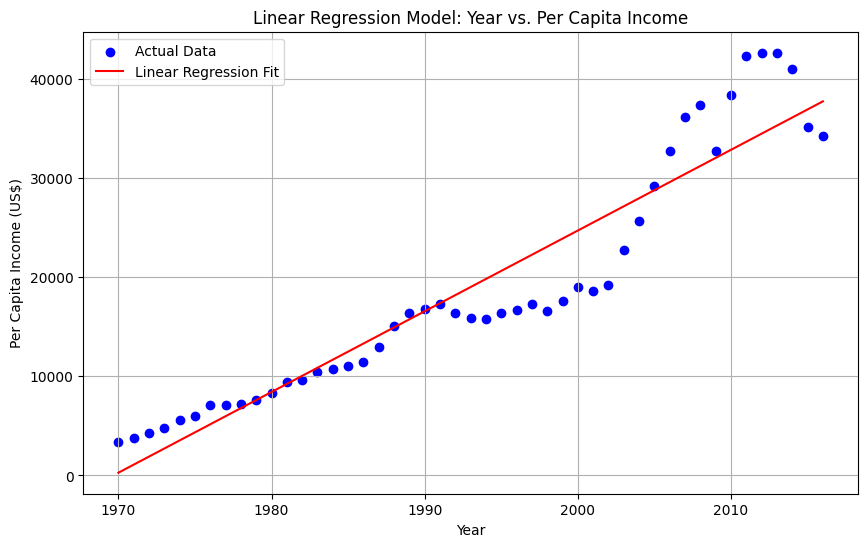

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

file_name = "canada_per_capita_income.csv"
df = pd.read_csv(file_name)

print(df.head())
print(df.info())

df.columns = ['year', 'per_capita_income_us']

X = df['year'].values.reshape(-1, 1)

y = df['per_capita_income_us'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nR-squared (R^2) Score: {r2}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

y_all_pred = model.predict(X)
r2_all = r2_score(y, y_all_pred)
print(f"R-squared (R^2) Score on full dataset: {r2_all}")

print(f"Model Coefficient (slope): {model.coef_[0]}")
print(f"Model Intercept: {model.intercept_}")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_all_pred, color='red', label='Linear Regression Fit')
plt.xlabel('Year')
plt.ylabel('Per Capita Income (US\$)')
plt.title('Linear Regression Model: Year vs. Per Capita Income')
plt.legend()
plt.grid(True)
plt.savefig('linear_regression_fit.png')